## DLR-PCG Computational Times

This notebook tests out the DLR-PCG computational times for different preconditioners.

Based on the results, an incomplete Cholesky preconditioner (IC) generally performs best. I therefore set `preconditioner='ic'` as default.

---

In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from time import time
from fenics import Function, FunctionSpace, plot

from utils.colors import C2, C3, C5, CMAP
from algorithms.dynamical_low_rank_pcg import DynamicalLowRankPCG
from utils.mesh_utils import get_square_f, get_square_mesh, get_L_mesh
from algorithms.matrix_free_rsvd import MatrixFreeRSVD, get_approximate_W
from utils.utils import progress_bar
from pathlib import Path

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 13,
    'text.usetex': True,
    'text.latex.preamble': r'\usepackage{amsfonts}'
})

SEED = 15
M = ['o', '*', '^', 's']
MS = [6, 8, 6, 5.5]

In [ ]:
n = 128
problem_params = {
    'I': {'mesh': get_square_mesh, 'n': n, 'width': 0.15, 'height': 0.15,
          'x0': [0.2], 'y0': [0.2]},
    'II': {'mesh': get_square_mesh, 'n': n, 'width': 0.15, 'height': 0.15,
           'x0': [0.1, 0.75, 0.15], 'y0': [0.1, 0.75, 0.70]},
    'III': {'mesh': get_L_mesh, 'n': n, 'width': 0.25, 'height': 0.25,
            'x0': [0.2, 1.55], 'y0': [0.2, 0.55]}
}

def get_source(V_h, x0_list, y0_list, width, height):
    x = np.zeros(V_h.dim())
    for x0, y0 in zip(x0_list, y0_list):
        f = get_square_f(V_h, x0=x0, y0=y0, w=width, h=height)
        x += f.vector().get_local()

    f = Function(V_h)
    f.vector()[:] = x
    return f, x


def problem_setup(params):
    # Function space setup
    mesh = params['mesh'](params['n'])
    V_h = FunctionSpace(mesh, 'CG', 1)
    rsvd = MatrixFreeRSVD(V_h)

    # Source setup
    f, x = get_source(
        V_h, params['x0'], params['y0'], 
        params['width'], params['height']
    )
    y = rsvd.apply_K(x)
    problem = {'V_h': V_h, 'rsvd': rsvd, 'f': f, 'x': x, 'y': y}
    return problem


def problems_setup(problem_params):
    problems =  {}
    for key, params in problem_params.items():
        print(f"Setting up problem {key}: ", end='')
        pb = problem_setup(params)
        print(f" N_b={pb['rsvd'].N_b}, N={pb['rsvd'].N} (done)")
        problems[key] = pb
    return problems


problems = problems_setup(problem_params)

Setting up problem I:  N_b=512, N=16641 (done)
Setting up problem II:  N_b=512, N=16641 (done)
Setting up problem III:  N_b=596, N=24239 (done)


In [4]:
def figure_problems(problems, fig_name=None):
    fig, axes = plt.subplots(1, 3, figsize=(8, 3))

    for ax, prob in zip(axes, ['I', 'II', 'III']):
        f = problems[prob]['f']
        plt.sca(ax)
        p = plot(f, cmap=CMAP)

        ax.set_xticks([])
        ax.set_yticks([])

    cax = fig.add_axes([0.913, 0.162, 0.015, 0.666]) # [left, bottom, width, height]
    norm = mcolors.Normalize(vmin=0.0, vmax=1.0)
    fig.colorbar(p, cax=cax, format="%.1f", norm=norm, shrink=0.8)
    plt.subplots_adjust(wspace=0.05)
    plt.show()

#figure_problems(problems)

In [5]:
def problem_init(n):
    V_h = FunctionSpace(get_square_mesh(n), 'CG', 1)
    mfrsvd = MatrixFreeRSVD(V_h)
    mfrsvd.mf_rsvd(k=min(30, mfrsvd.N_b))
    w = get_approximate_W(mfrsvd.VkT.T, mfrsvd.M_dx)
    _, x = get_source(V_h, [0.1, 0.75, 0.15], [0.1, 0.75, 0.70], 0.15, 0.15)
    y = mfrsvd.apply_K(x)
    return V_h, mfrsvd, w, x, y


def experiment_precond_meshes(n_range, rtols, precond, solver_params, repeats=1):
    record = []
    n_steps = len(n_range) * len(rtols) * repeats
    step = 0
    
    for n in n_range:
        _, mfrsvd, w, _, y = problem_init(n)
        solver = DynamicalLowRankPCG(mfrsvd)

        for r in range(repeats):
            for rtol in rtols:
                t0 = time()
                solver.solve(y, w, rtol=rtol, preconditioner=precond, verbose=False, **solver_params)
                t = time() - t0
                record.append({'r': r, 'rtol': rtol, 'N': mfrsvd.N, 'N_b': mfrsvd.N_b, 't': t})

                step +=1
                progress_bar(step, n_steps, end_text=f' [{n=}, {precond}]')

    return pd.DataFrame(record)


def save_results(results: dict):

    results_dir = Path("../results")

    for precond, df in results.items():
        medians = (
            df
            .groupby(['rtol', 'N', 'N_b'], as_index=False)['t']
            .median()
        )
        file_path = results_dir / f'precondition_{str(precond)}.csv'
        if not file_path.exists():
            print(f"Saving {file_path}")
            medians.to_csv(file_path)


run = True
N_range = np.linspace(100, 2e5, 15)
n_range = np.sqrt(N_range).astype(int)
rtols = [1e-6, 1e-8, 1e-10]
solver_params = {'lambda_': 1e-5, 'max_rank': 2, 'max_iter': 250}
if run:
    results_ts = {}

    for precond in [None, 'jacobi', 'ic-woodbury', 'cholesky']:
        df = experiment_precond_meshes(n_range, rtols, precond, solver_params, repeats=15)
        results_ts[str(precond).lower()] = df

    save_results(results_ts)

[##############################] 675/675 [n=447, None]
[##############################] 675/675 [n=447, jacobi]
[##############################] 675/675 [n=447, ic-woodbury]
[##############################] 675/675 [n=447, cholesky]
Saving ../results/precondition_none.csv
Saving ../results/precondition_jacobi.csv
Saving ../results/precondition_ic-woodbury.csv
Saving ../results/precondition_cholesky.csv


In [11]:
preconditioners = ['none', 'jacobi', 'cholesky', 'ic-woodbury']
medians = {}
for precond in preconditioners:
    file_path = Path(f"../results/precondition_{precond}.csv")
    medians[precond] = pd.read_csv(file_path)

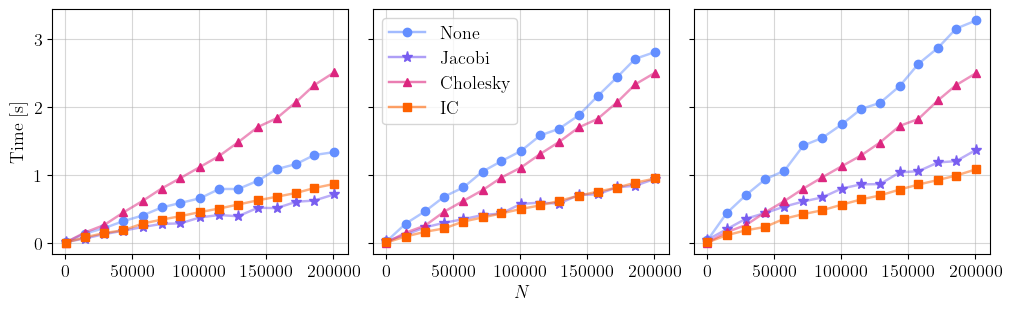

In [ ]:
def save_plot(fig_name: str) -> None:
    if fig_name is not None:
        path = Path(f"../figures/{fig_name}.png")
        if not path.exists():
            plt.savefig(path, dpi=300, bbox_inches="tight")
        else:
            print(path, 'already exists')


def plot_medians(medians, fig_name=None):
    from matplotlib.lines import Line2D

    fig, axes = plt.subplots(1, 3, figsize=(10, 3), constrained_layout=True, sharey=True)
    axes = axes.flatten()

    titles = {'none': 'None', 'jacobi': 'Jacobi', 'cholesky': 'Cholesky', 'ic-woodbury': 'IC'}
    for i, rtol in enumerate(rtols):
        ax = axes[i]

        for j, (precond, df) in enumerate(medians.items()):
            dfr = df[df.rtol == rtol]
            ax.plot(dfr['N'], dfr['t'], c=C5[j], alpha=0.5, lw=1.75)
            ax.plot(dfr['N'], dfr['t'], M[j], c=C5[j], ms=MS[j])

        handles, labels = [], []
        for j, precond in enumerate(medians.keys()):
            legend_line = Line2D([0], [0], color=C5[j], linewidth=1.75, alpha=0.5)
            legend_marker = Line2D([0], [0], color=C5[j], marker=M[j], markersize=MS[j], linestyle='None')
            handles.append((legend_line, legend_marker))
            labels.append(titles[precond])

        #ax.set_title(f"rtol={rtol}")
        ax.grid(True, alpha=0.5)

    axes[1].legend(handles=handles, labels=labels)
    axes[1].set_xlabel('$N$')
    axes[0].set_ylabel('Time [s]')

    save_plot(fig_name)
    plt.show()


plot_medians(medians, fig_name='precondition_times')

In [8]:
def compare_precond(problem_id, problems, k=50, lambda_=1e-4, max_rank=5, max_iter=100, rtol=1e-8):
    p = problems[problem_id]
    mfrsvd = MatrixFreeRSVD(p['V_h'])
    mfrsvd.mf_rsvd(k=k)
    w = get_approximate_W(mfrsvd.VkT.T, mfrsvd.M_dx)

    results = []
    for pre in [None, 'jacobi', 'cholesky', 'ic-woodbury']:
        solver = DynamicalLowRankPCG(mfrsvd)

        t0 = time()
        x_hat = solver.solve(
            p['y'], w, lambda_=lambda_, max_rank=max_rank,
            max_iter=max_iter, preconditioner=pre, rtol=rtol
        )
        dt = time() - t0

        f_hat = Function(p['V_h'])
        f_hat.vector()[:] = x_hat
        results.append({
            'precondition': pre, 'solver': solver,
            'x_hat': x_hat, 'f_hat': f_hat, 'dt': dt
        })
    return results

solver_params = {'lambda_': 1e-5, 'max_rank': 2, 'max_iter': 200, 'rtol': 1e-12}
results = compare_precond('II', problems, **solver_params)

[##############################] 200/200
Converged at iter 155 [rel_res=9.22e-13]
Converged at iter 1 [rel_res=7.37e-14]
Converged at iter 15 [rel_res=5.43e-13]


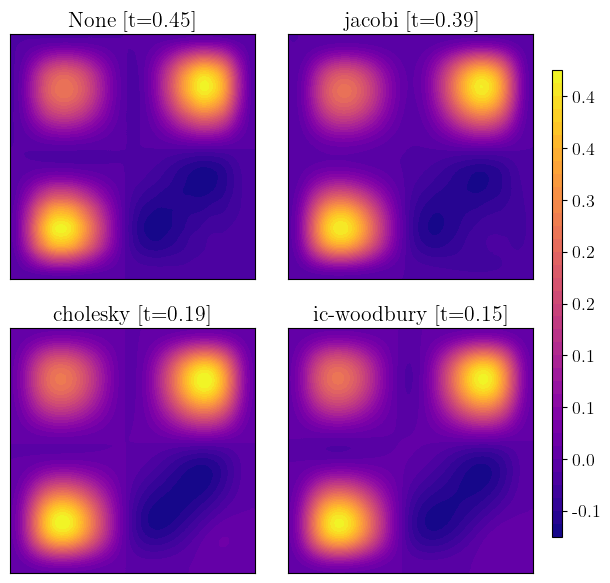

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(7, 7))
axes = axes.flatten()

for ax, r in zip(axes, results):
    plt.sca(ax)
    p = plot(r['f_hat'], cmap=CMAP)
    ax.set_title(f"{r['precondition']} [t={r['dt']:.2f}]")
    ax.set_xticks([])
    ax.set_yticks([])

cax = fig.add_axes([0.913, 0.162, 0.015, 0.666]) # [left, bottom, width, height]
norm = mcolors.Normalize(vmin=0.0, vmax=1.0)
fig.colorbar(p, cax=cax, format="%.1f", norm=norm, shrink=0.8)
plt.subplots_adjust(wspace=0.05)
plt.show()

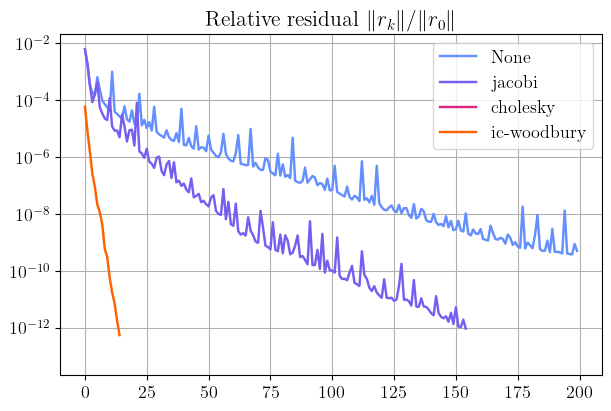

In [10]:
from utils.colors import C5

fig, ax1 = plt.subplots(1, 1, figsize=(6, 4), constrained_layout=True)


for i, r in enumerate(results):
    ax1.semilogy(r['solver'].residual, label=str(r['precondition']), c=C5[i], lw=1.75)
    ax1.set_title('Relative residual $\|r_k\| / \|r_0\|$')


ax1.legend()
ax1.grid(0.5)

plt.show()